<a href="https://colab.research.google.com/github/ayaanc14/Coral-Reef-Model/blob/main/Coral_Reef.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Coral Reef Analysis
Analysis of dataset which contains observations of synthetic data modelled on characteristics of coral reefs.

Dataset uploaded by Peter Moorhouse on Kaggle, last updated July 2025

# We random split(train, val, test) the dataset:

Train - 80% (For training the models).

Val - 10% (For hyperparameter tuning/model validation).

Test - 10% (For acessing the model performance).

# Format
CSV with 23 columns such as region, water_temperature and true or false variable for each species type

### Machine Learning Algorithms for Coral Reef Region Prediction

Given that 'region' is a categorical variable, this is a **multi-class classification problem**. Here are some commonly used algorithms that would be suitable:

1.  **Logistic Regression**: A simple yet powerful linear model. It's a good baseline and provides probabilities for each class.
2.  **Decision Trees**: These are intuitive and can capture non-linear relationships. They are also easy to interpret.
3.  **Random Forest**: An ensemble method that builds multiple decision trees and merges their predictions. It generally offers higher accuracy and better generalization than a single decision tree.
4.  **Support Vector Machines (SVM)**: Effective in high-dimensional spaces and for cases where the number of dimensions is greater than the number of samples. Can use various kernel functions to handle non-linear data.
5.  **Gradient Boosting (e.g., XGBoost, LightGBM, CatBoost)**: Powerful ensemble methods that build models sequentially, with each new model correcting errors made by previous ones. Often achieve state-of-the-art results on tabular data.
6.  **K-Nearest Neighbors (KNN)**: A non-parametric, instance-based learning algorithm that classifies data points based on the majority class of their 'k' nearest neighbors.
7.  **Neural Networks (e.g., Multi-layer Perceptron)**: Can capture complex non-linear patterns, especially useful if you have a very large dataset and complex interactions between features.

### Data Preparation for Modeling

Before applying these algorithms, you'll need to prepare your data. Key steps usually include:

*   **Feature Selection/Engineering**: Deciding which columns to use as predictors.
*   **Handling Categorical Variables**: Encoding `object` type columns (like `substrate_type`, `light_availability`, `marine_protection_status`) into numerical representations.
*   **Scaling Numerical Features**: Algorithms like SVM and Logistic Regression can benefit from numerical features being scaled (e.g., using `StandardScaler`).
*   **Splitting Data**: Dividing your dataset into training, validation, and test sets.

In [1]:
#mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#create folder in drive for dataset
!mkdir -p '/content/drive/MyDrive/Kaggle/coral_reef'

In [3]:
#upload kaggle api
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ayaan14","key":"d06e859de358b17b72b9842de9d55cae"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
#download dataset from kaggle to drive
!kaggle datasets download -d petermoorhouse/coral-reef-sites -p '/content/drive/MyDrive/Kaggle/coral_reef'

Dataset URL: https://www.kaggle.com/datasets/petermoorhouse/coral-reef-sites
License(s): CC0-1.0
coral-reef-sites.zip: Skipping, found more recently modified local copy (use --force to force download)


In [6]:
#unzip dataset in drive
!unzip '/content/drive/MyDrive/Kaggle/coral_reef/coral-reef-sites.zip' -d '/content/drive/MyDrive/Kaggle/coral_reef/'

Archive:  /content/drive/MyDrive/Kaggle/coral_reef/coral-reef-sites.zip
replace /content/drive/MyDrive/Kaggle/coral_reef/coral_reef_sites.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/drive/MyDrive/Kaggle/coral_reef/coral_reef_sites.csv  


In [7]:
#load dataset onto pandas
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Kaggle/coral_reef/coral_reef_sites.csv')
df.head()

,id,region,depth,substrate_type,structural_complexity,water_temperature,salinity,light_availability,coral_cover,algal_cover,...,species_Favia,species_Stylophora,species_Acropora,species_Goniastrea,species_Montipora,species_Pocillopora,species_Montastraea,species_Orbicella,species_Siderastrea,species_Fungia
0,1,Red Sea,20.7,Rubble,0.55,28.8,40.9,Low,60.8,5.8,...,1,0,0,0,0,0,0,0,0,0
1,2,Red Sea,25.9,Sandy,0.86,27.0,40.6,Low,50.9,7.5,...,1,0,0,0,0,0,0,0,0,0
2,3,Red Sea,11.3,Rubble,0.71,27.9,40.4,Medium,55.1,16.1,...,0,1,0,0,0,0,0,0,0,0
3,4,Red Sea,30.0,Sandy,0.77,26.6,40.4,Low,60.8,27.5,...,0,0,0,0,0,0,0,0,0,0
4,5,Red Sea,12.3,Rubble,0.83,29.7,39.2,Medium,64.9,13.6,...,0,1,0,0,0,0,0,0,0,0


In [8]:
#calculate total number of null values
df.isnull().sum()

,0
id,0
region,0
depth,0
substrate_type,0
structural_complexity,0
water_temperature,0
salinity,0
light_availability,0
coral_cover,0
algal_cover,0


In [9]:
#view the data types of each column
df.dtypes

,0
id,int64
region,object
depth,float64
substrate_type,object
structural_complexity,float64
water_temperature,float64
salinity,float64
light_availability,object
coral_cover,float64
algal_cover,float64


In [10]:
#check for any duplicate rows, remove duplicates if found
df.duplicated().sum()
df[df.duplicated()]
df_clean = df.drop_duplicates()


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           10000 non-null  int64  
 1   region                       10000 non-null  object 
 2   depth                        10000 non-null  float64
 3   substrate_type               10000 non-null  object 
 4   structural_complexity        10000 non-null  float64
 5   water_temperature            10000 non-null  float64
 6   salinity                     10000 non-null  float64
 7   light_availability           10000 non-null  object 
 8   coral_cover                  10000 non-null  float64
 9   algal_cover                  10000 non-null  float64
 10  marine_protection_status     10000 non-null  object 
 11  proximity_to_human_activity  10000 non-null  float64
 12  species_Porites              10000 non-null  int64  
 13  species_Favia    

In [12]:
#Calculating the number of rows and columns
df.shape

(10000, 23)

This code prepares your data by encoding categorical features, encoding the target variable, splitting the data, and scaling numerical features. You can now use `X_train`, `y_train`, `X_val`, `y_val`, `X_test`, and `y_test` to train and evaluate your chosen machine learning models.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

# Assuming df is your loaded DataFrame from previous steps
df_clean = df.drop_duplicates() # Moved this line here to ensure df_clean is defined

# Identify target variable and features
X = df_clean.drop(['id', 'region'], axis=1) # Drop 'id' as it's just an identifier, 'region' is our target
y = df_clean['region']

# Handle categorical features using one-hot encoding
X = pd.get_dummies(X, columns=['substrate_type', 'light_availability', 'marine_protection_status'], drop_first=True)

# Encode the target variable 'region'
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training, validation, and test sets
# First, split into training and a temporary set (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Then, split the temporary set into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Scale numerical features (optional, but often beneficial for many algorithms)
# Identify numerical columns after one-hot encoding
numerical_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

# Display the first few rows of the processed training features
display(X_train.head())

Shape of X_train: (8000, 25)
Shape of y_train: (8000,)
Shape of X_val: (1000, 25)
Shape of y_val: (1000,)
Shape of X_test: (1000, 25)
Shape of y_test: (1000,)


,depth,structural_complexity,water_temperature,salinity,coral_cover,algal_cover,proximity_to_human_activity,species_Porites,species_Favia,species_Stylophora,...,species_Orbicella,species_Siderastrea,species_Fungia,substrate_type_Rocky,substrate_type_Rubble,substrate_type_Sandy,substrate_type_Silty,light_availability_Low,light_availability_Medium,marine_protection_status_Unprotected
4045,0.164615,1.203169,0.546218,-0.675775,0.295042,1.590971,-0.679561,0.734606,-0.372545,-0.381412,...,-0.381412,-0.379259,2.777516,True,False,False,False,False,True,True
3207,-0.299509,-0.611252,-0.029169,1.852989,-1.187501,-0.691308,-0.471963,-1.361274,2.684237,2.621834,...,-0.381412,-0.379259,-0.360034,False,False,True,False,False,True,True
2543,0.938154,-1.367261,1.377331,-0.465045,-1.245075,-0.453279,-1.060158,-1.361274,-0.372545,-0.381412,...,-0.381412,-0.379259,2.777516,False,True,False,False,True,False,True
8836,-0.078498,-0.006445,1.377331,1.515820,-0.942809,1.100911,-0.519144,0.734606,-0.372545,2.621834,...,-0.381412,-0.379259,-0.360034,False,False,True,False,False,True,True
1613,-1.271958,-0.460050,0.354422,-0.254315,1.014723,-1.251377,-0.688997,0.734606,-0.372545,-0.381412,...,2.621834,2.636719,-0.360034,False,False,False,False,False,False,False


### Correlation Heatmap of Numerical Features

To understand the relationships between the various numerical features, we can visualize their correlation matrix using a heatmap. This can highlight positive or negative correlations and help identify features that might be redundant or strongly associated with each other.

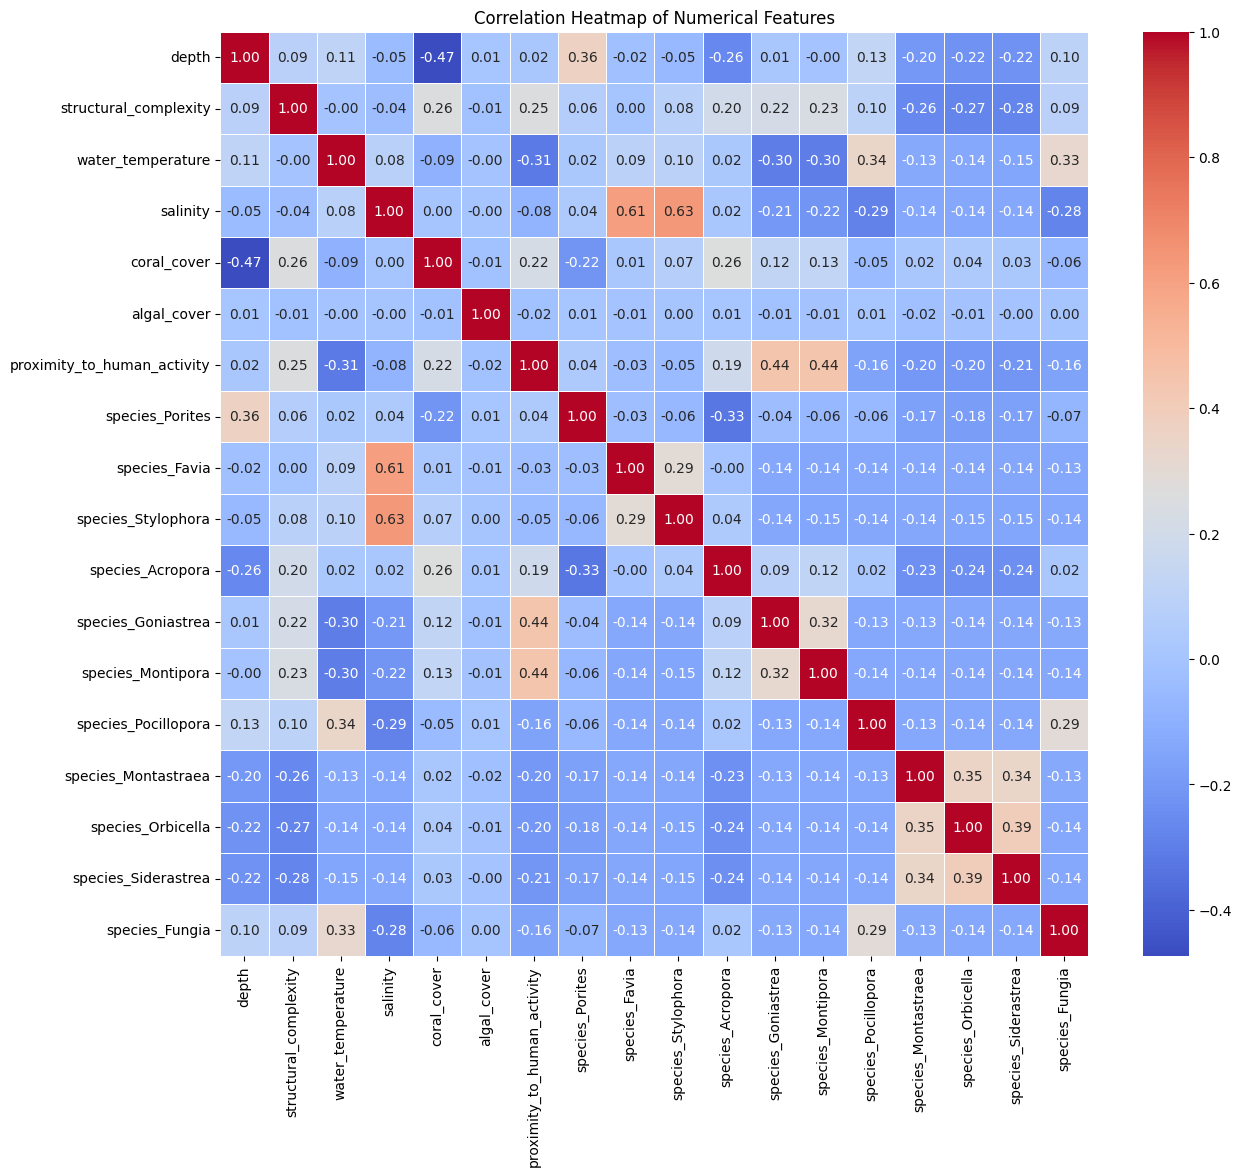

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
numerical_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns

# Exclude 'id' and species columns if they are not considered numerical features for correlation insight
# For this example, let's keep all numerical columns for a broad view, but in practice,
# you might want to exclude 'id' and species if they are just binary indicators or identifiers.
# Let's create a subset excluding 'id' for a cleaner correlation matrix related to environmental factors.

correlation_matrix = df_clean[numerical_cols].drop(columns=['id'], errors='ignore').corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Random Forest Classifier model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [16]:
# Make predictions on the validation set
y_pred_val = rf_model.predict(X_val)

# Evaluate the model's performance on the validation set
accuracy = accuracy_score(y_val, y_pred_val)
print(f"Validation Accuracy: {accuracy:.4f}")

# Display a detailed classification report
print("\nClassification Report (Validation Set):")
print(classification_report(y_val, y_pred_val, target_names=label_encoder.classes_))

Validation Accuracy: 0.9950

Classification Report (Validation Set):
                    precision    recall  f1-score   support

         Caribbean       1.00      1.00      1.00       249
    Coral Triangle       0.99      0.99      0.99       245
Great Barrier Reef       1.00      0.99      0.99       248
           Red Sea       1.00      1.00      1.00       258

          accuracy                           0.99      1000
         macro avg       0.99      0.99      0.99      1000
      weighted avg       1.00      0.99      0.99      1000



In [17]:
import pandas as pd

# Get feature importances from the trained model
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

# Sort feature importances in descending order
sorted_feature_importances = feature_importances.sort_values(ascending=False)

# Display the top 10 most important features
print("\nTop 10 Most Important Features:")
display(sorted_feature_importances.head(10))


Top 10 Most Important Features:


,0
salinity,0.300254
proximity_to_human_activity,0.086288
water_temperature,0.072603
species_Orbicella,0.070617
species_Siderastrea,0.066593
species_Montipora,0.066111
species_Pocillopora,0.051497
species_Fungia,0.045587
species_Montastraea,0.043702
species_Goniastrea,0.043180


The model has been trained and evaluated on the validation set. We can see the overall accuracy and detailed metrics for each region. To get a final unbiased evaluation of the model's performance, we will now evaluate it on the unseen test set.

In [18]:
# Make predictions on the test set
y_pred_test = rf_model.predict(X_test)

# Evaluate the model's performance on the test set
accuracy_test = accuracy_score(y_test, y_pred_test)
print(f"Test Accuracy: {accuracy_test:.4f}")

# Display a detailed classification report for the test set
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_))

Test Accuracy: 0.9970

Classification Report (Test Set):
                    precision    recall  f1-score   support

         Caribbean       1.00      0.99      1.00       250
    Coral Triangle       0.99      1.00      1.00       245
Great Barrier Reef       1.00      1.00      1.00       248
           Red Sea       1.00      1.00      1.00       257

          accuracy                           1.00      1000
         macro avg       1.00      1.00      1.00      1000
      weighted avg       1.00      1.00      1.00      1000



In [19]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# Initialize the XGBoost Classifier model
# Using use_label_encoder=False and eval_metric='mlogloss' for multi-class classification with XGBoost 1.x+
# This is done to suppress a common warning in newer versions of XGBoost.
# It assumes y_encoded values are 0 to num_classes-1
# 'objective':'multi:softmax' for multi-class classification, outputs class labels directly
# 'num_class' should be set to the number of unique classes in your target variable

# Get the number of classes from the label_encoder
num_classes = len(label_encoder.classes_)

# For multi-class classification with label-encoded targets, 'multi:softmax' or 'multi:softprob' can be used.
# 'multi:softmax' will output the predicted class directly.
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss',
    use_label_encoder=False, # Suppress warning for newer XGBoost versions
    n_estimators=100,
    random_state=42,
    tree_method='hist' # Often faster for larger datasets
)

# Train the model on the training data
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:08:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained successfully!


In [20]:
# Make predictions on the validation set
y_pred_val_xgb = xgb_model.predict(X_val)

# Evaluate the model's performance on the validation set
accuracy_xgb_val = accuracy_score(y_val, y_pred_val_xgb)
print(f"XGBoost Validation Accuracy: {accuracy_xgb_val:.4f}")

# Display a detailed classification report
print("\nClassification Report (XGBoost Validation Set):")
print(classification_report(y_val, y_pred_val_xgb, target_names=label_encoder.classes_))

XGBoost Validation Accuracy: 0.9940

Classification Report (XGBoost Validation Set):
                    precision    recall  f1-score   support

         Caribbean       1.00      1.00      1.00       249
    Coral Triangle       0.99      0.99      0.99       245
Great Barrier Reef       0.99      0.99      0.99       248
           Red Sea       1.00      1.00      1.00       258

          accuracy                           0.99      1000
         macro avg       0.99      0.99      0.99      1000
      weighted avg       0.99      0.99      0.99      1000



In [21]:
import pandas as pd

# Get feature importances from the trained XGBoost model
# XGBoost's feature_importances_ often provides 'gain' or 'weight' by default
# This assumes the model has been fitted.
feature_importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_train.columns)

# Sort feature importances in descending order
sorted_feature_importances_xgb = feature_importances_xgb.sort_values(ascending=False)

# Display the top 10 most important features
print("\nTop 10 Most Important Features (XGBoost):")
display(sorted_feature_importances_xgb.head(10))


Top 10 Most Important Features (XGBoost):


,0
species_Orbicella,0.234150
species_Siderastrea,0.153480
species_Montipora,0.147810
species_Goniastrea,0.106633
species_Montastraea,0.087082
species_Pocillopora,0.065795
salinity,0.059622
species_Fungia,0.050401
substrate_type_Silty,0.046710
water_temperature,0.012994


The XGBoost model has been trained and evaluated on the validation set. Now, let's evaluate its performance on the unseen test set for a final, unbiased assessment.

In [22]:
# Make predictions on the test set
y_pred_test_xgb = xgb_model.predict(X_test)

# Evaluate the model's performance on the test set
accuracy_xgb_test = accuracy_score(y_test, y_pred_test_xgb)
print(f"XGBoost Test Accuracy: {accuracy_xgb_test:.4f}")

# Display a detailed classification report for the test set
print("\nClassification Report (XGBoost Test Set):")
print(classification_report(y_test, y_pred_test_xgb, target_names=label_encoder.classes_))

XGBoost Test Accuracy: 0.9980

Classification Report (XGBoost Test Set):
                    precision    recall  f1-score   support

         Caribbean       1.00      1.00      1.00       250
    Coral Triangle       0.99      1.00      1.00       245
Great Barrier Reef       1.00      0.99      1.00       248
           Red Sea       1.00      1.00      1.00       257

          accuracy                           1.00      1000
         macro avg       1.00      1.00      1.00      1000
      weighted avg       1.00      1.00      1.00      1000



In [23]:
#display feature importance for random forest
print("Random Forest Feature Importances (Sorted):")
display(sorted_feature_importances)

Random Forest Feature Importances (Sorted):


,0
salinity,0.300254
proximity_to_human_activity,0.086288
water_temperature,0.072603
species_Orbicella,0.070617
species_Siderastrea,0.066593
species_Montipora,0.066111
species_Pocillopora,0.051497
species_Fungia,0.045587
species_Montastraea,0.043702
species_Goniastrea,0.043180



Based on the analysis of feature importances, I will select the features that have an importance score above a certain threshold (e.g., 0.01) to create a subset of features for retraining the model. This step directly addresses the subtask's goal to identify features for a simpler, potentially more robust model.



In [24]:
importance_threshold = 0.01
selected_features = sorted_feature_importances[sorted_feature_importances >= importance_threshold].index.tolist()

print(f"Number of features with importance >= {importance_threshold}: {len(selected_features)}")
print("Selected Features:")
for feature in selected_features:
    print(f"- {feature}")

# Filter the datasets to include only the selected features
X_train_selected = X_train[selected_features]
X_val_selected = X_val[selected_features]
X_test_selected = X_test[selected_features]

print("\nShape of X_train_selected:", X_train_selected.shape)
print("Shape of X_val_selected:", X_val_selected.shape)
print("Shape of X_test_selected:", X_test_selected.shape)

Number of features with importance >= 0.01: 15
Selected Features:
- salinity
- proximity_to_human_activity
- water_temperature
- species_Orbicella
- species_Siderastrea
- species_Montipora
- species_Pocillopora
- species_Fungia
- species_Montastraea
- species_Goniastrea
- species_Stylophora
- species_Favia
- structural_complexity
- species_Acropora
- depth

Shape of X_train_selected: (8000, 15)
Shape of X_val_selected: (1000, 15)
Shape of X_test_selected: (1000, 15)


**Reasoning**:
I will retrain the Random Forest Classifier using only the `X_train_selected` dataset, which contains features identified as most important. This step directly implements the feature selection and model retraining aspect of the task.



In [25]:
from sklearn.ensemble import RandomForestClassifier

# Initialize a new Random Forest Classifier model
rf_model_selected_features = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data with selected features
rf_model_selected_features.fit(X_train_selected, y_train)

print("Random Forest model trained successfully with selected features!")

Random Forest model trained successfully with selected features!


**Reasoning**:
I will evaluate the performance of the newly trained Random Forest model (rf_model_selected_features) on the test set (`X_test_selected`, `y_test`) by making predictions and calculating the accuracy and classification report. This addresses the task's requirement to evaluate the adapted model's performance.



In [26]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test set using the model with selected features
y_pred_test_selected = rf_model_selected_features.predict(X_test_selected)

# Evaluate the model's performance on the test set
accuracy_test_selected = accuracy_score(y_test, y_pred_test_selected)
print(f"Test Accuracy (with selected features): {accuracy_test_selected:.4f}")

# Display a detailed classification report for the test set
print("\nClassification Report (Test Set with Selected Features):")
print(classification_report(y_test, y_pred_test_selected, target_names=label_encoder.classes_))

Test Accuracy (with selected features): 0.9930

Classification Report (Test Set with Selected Features):
                    precision    recall  f1-score   support

         Caribbean       0.99      0.98      0.99       250
    Coral Triangle       0.99      1.00      0.99       245
Great Barrier Reef       0.99      0.99      0.99       248
           Red Sea       1.00      1.00      1.00       257

          accuracy                           0.99      1000
         macro avg       0.99      0.99      0.99      1000
      weighted avg       0.99      0.99      0.99      1000

